# Лабораторная работа №5

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from math import sqrt, ceil, log2
from sklearn.model_selection import train_test_split

Добавим заголовки

In [30]:
columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color", "ring-number",
    "ring-type", "spore-print-color", "population", "habitat"
]

df = pd.read_csv("agaricus-lepiota.data", header=None, names=columns)
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [32]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [33]:
print(df['veil-type'].value_counts())

veil-type
p    8124
Name: count, dtype: int64


Колонка 'veil-type' неинформативна т.к. содержит только одно значение 'p' для всех записей

In [34]:
df = df.drop('veil-type', axis=1)

Преобразуем строковые признаки в числовые

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,...,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000
mean,0.482029,3.348104,1.827671,4.504677,0.415559,4.144756,0.974151,0.161497,0.309207,4.810684,...,1.575086,1.603644,5.816347,5.794682,1.965534,1.069424,2.291974,3.596750,3.644018,1.508616
std,0.499708,1.604329,1.229873,2.545821,0.492848,2.103729,0.158695,0.368011,0.462195,3.540359,...,0.621459,0.675974,1.901747,1.907291,0.242669,0.271064,1.801672,2.382663,1.252082,1.719975
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,3.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,...,1.000000,1.000000,6.000000,6.000000,2.000000,1.000000,0.000000,2.000000,3.000000,0.000000
50%,0.000000,3.000000,2.000000,4.000000,0.000000,5.000000,1.000000,0.000000,0.000000,5.000000,...,2.000000,2.000000,7.000000,7.000000,2.000000,1.000000,2.000000,3.000000,4.000000,1.000000
75%,1.000000,5.000000,3.000000,8.000000,1.000000,5.000000,1.000000,0.000000,1.000000,7.000000,...,2.000000,2.000000,7.000000,7.000000,2.000000,1.000000,4.000000,7.000000,4.000000,2.000000
max,1.000000,5.000000,3.000000,9.000000,1.000000,8.000000,1.000000,1.000000,1.000000,11.000000,...,3.000000,3.000000,8.000000,8.000000,3.000000,2.000000,4.000000,8.000000,5.000000,6.000000


Построим гистрограммы

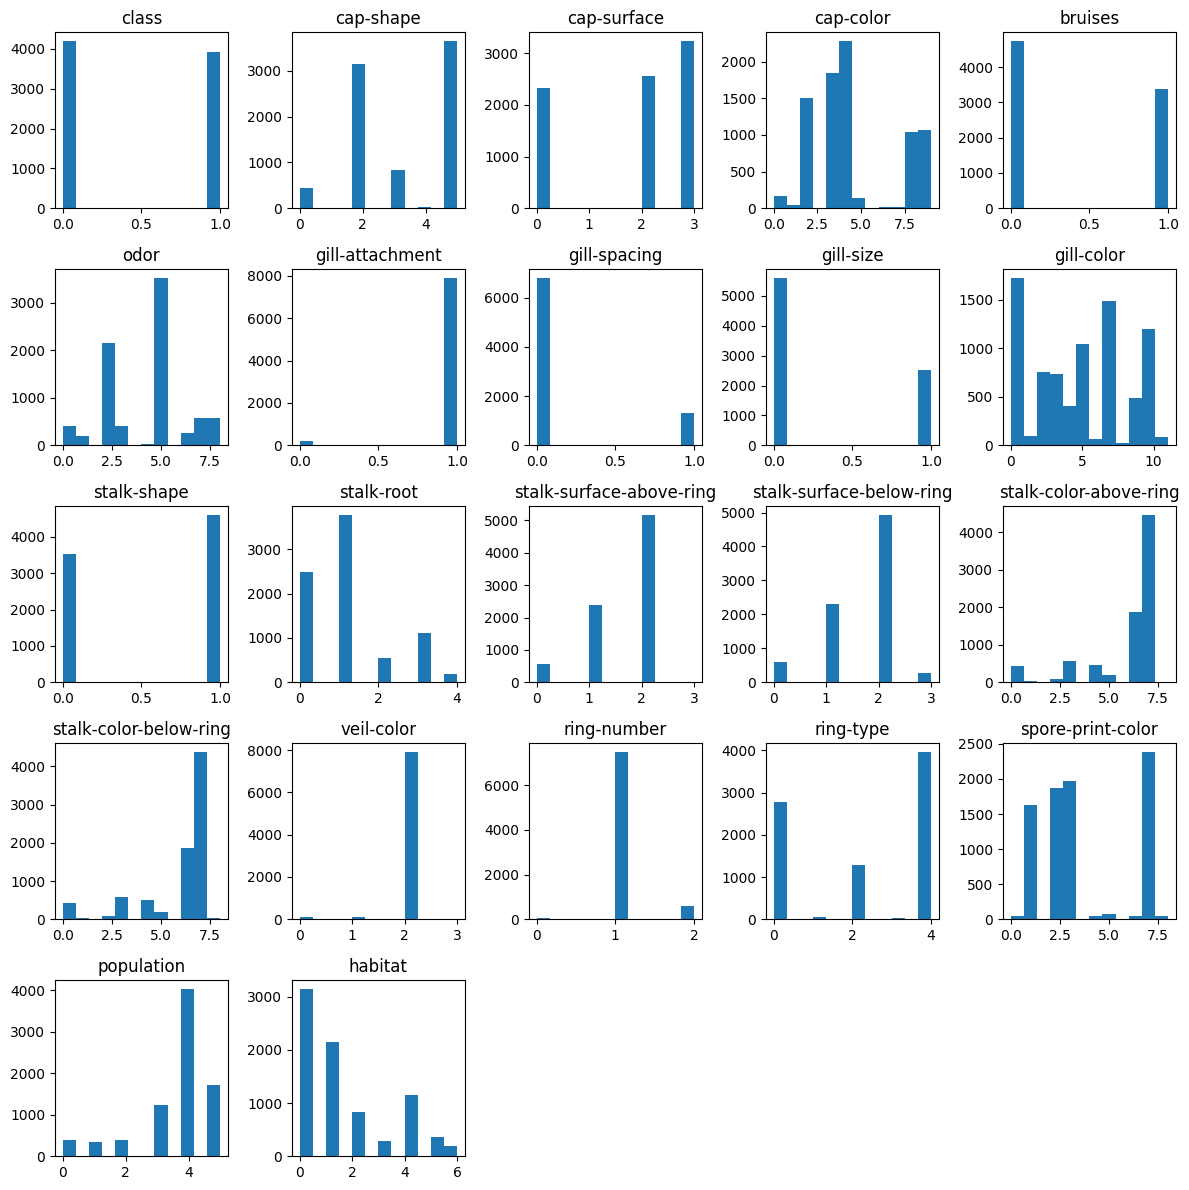

In [36]:
ax = df.hist(bins=12, figsize=(12, 12))
for axis in ax.flatten():
    axis.grid(False)
plt.tight_layout()
plt.show()

Гистограмма целевого класса

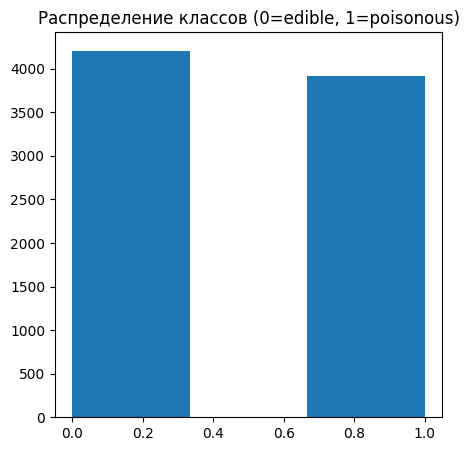

In [37]:
y = df['class']
ax = y.hist(bins=3, figsize=(5, 5))
ax.grid(False)
plt.title("Распределение классов (0=edible, 1=poisonous)")
plt.show()

Случайный отбор признаков

In [38]:
np.random.seed(42)

X = df.drop('class', axis=1)
columns_list = X.columns

num_features_to_select = ceil(sqrt(len(columns_list)))
selected_columns = np.random.choice(columns_list, num_features_to_select, replace=False)

X = X[selected_columns]

print(f"Отобрано {num_features_to_select} признаков: {selected_columns}")
X.head()

Отобрано 5 признаков: ['cap-shape' 'ring-type' 'veil-color' 'cap-surface' 'gill-color']


,cap-shape,ring-type,veil-color,cap-surface,gill-color
0,5,4,2,2,4
1,5,4,2,2,4
2,0,4,2,2,5
3,5,4,2,3,5
4,5,0,2,2,4


Сплит на train/test

In [39]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Размер обучающей выборки:", len(x_train))
print("Размер тестовой выборки:", len(x_test))

Размер обучающей выборки: 6499
Размер тестовой выборки: 1625


## Реализация дерева решений

### Класс узла

In [1]:
class Node:
    def __init__(self, feature=None, children=None, value=None, proba=None, is_leaf=False):
        self.feature = feature      # имя признака разделения
        self.children = children    # словарь: {значение признака : узел-потомок}
        self.value = value          # предсказанный класс (0 или 1) для этого узла
        self.proba = proba          # вероятность класса 1
        self.is_leaf = is_leaf      # флаг листа

Функция предсказания для одного объекта

In [44]:
def predict_single_item(node, row):
    if node.is_leaf or row[node.feature] not in node.children:
        return node.value, node.proba

    feature_val = row[node.feature]
    return predict_single_item(node.children[feature_val], row)

Расчет энтропии
- Если в группе только ядовитые грибы => Энтропия = 0 (порядок)
- Если 50/50 ядовитых и съедобных => Энтропия = 1 (хаос)

Формула: $H(S) = -\sum p_i log_2 (p_i)$

In [45]:
def calculate_entropy(y):
    if len(y) == 0:
        return 0.0

    p1 = y.mean()
    p0 = 1 - p1

    entropy = 0.0
    
    if p0 > 0:
        entropy -= p0 * np.log2(p0)
    if p1 > 0:
        entropy -= p1 * np.log2(p1)
        
    return entropy

Прирост информации

Information Gain = (энтропия до разбиения) - (взвешенная энтропия после разбиения)

In [47]:
def calculate_information_gain(X, y, feature_name):
    parent_entropy = calculate_entropy(y)
    
    unique_values = X[feature_name].unique()
    
    weighted_child_entropy = 0.0
    
    for val in unique_values:
        mask = X[feature_name] == val
        y_subset = y[mask]
        
        child_entropy = calculate_entropy(y_subset)
        
        weight = len(y_subset) / len(y)
        weighted_child_entropy += weight * child_entropy
        
    ig = parent_entropy - weighted_child_entropy
    return ig

Рекурсивное построение дерева

In [48]:
def build_tree(X, y, columns, depth, max_depth, min_samples=2):
    proba = y.mean()
    value = 1 if proba >= 0.5 else 0
    
    if (depth >= max_depth or 
        len(y.unique()) == 1 or 
        len(y) < min_samples or 
        len(columns) == 0):
        return Node(value=value, proba=proba, is_leaf=True)
    
    best_ig = -1
    best_feature = None
    
    for col in columns:
        ig = calculate_information_gain(X, y, col)
        if ig > best_ig:
            best_ig = ig
            best_feature = col
            
    if best_ig <= 1e-9:
        return Node(value=value, proba=proba, is_leaf=True)
    
    children = {}
    feature_values = X[best_feature].unique()
    
    remaining_cols = [c for c in columns if c != best_feature]
    
    for val in feature_values:
        mask = X[best_feature] == val
        X_subset = X[mask]
        y_subset = y[mask]
        
        children[val] = build_tree(
            X_subset, y_subset, remaining_cols, 
            depth + 1, max_depth, min_samples
        )
        
    return Node(value=value, proba=proba, is_leaf=False, 
                feature=best_feature, children=children)

Обертки

In [49]:
def fit(X_train, y_train, max_depth=5):
    return build_tree(X_train, y_train, X_train.columns, depth=0, max_depth=max_depth)

def predict(root, X_test):
    predictions = []
    probabilities = []
    
    for i in range(len(X_test)):
        row = X_test.iloc[i]
        val, prob = predict_single_item(root, row)
        predictions.append(val)
        probabilities.append(prob)
        
    return np.array(predictions), np.array(probabilities)

## Обучение и проверка

In [51]:
print(f"Признаки для обучения: {list(x_train.columns)}")
root_node = fit(x_train, y_train, max_depth=5)
print("Дерево построено")

y_pred, y_pred_proba = predict(root_node, x_test)

print("\nПервые 10 предсказаний (классы):", y_pred[:10])
print("Первые 10 вероятностей:", y_pred_proba[:10])
print("Первые 10 реальных меток:", y_test[:10].values)

Признаки для обучения: ['cap-shape', 'ring-type', 'veil-color', 'cap-surface', 'gill-color']
Дерево построено

Первые 10 предсказаний (классы): [1 1 0 1 1 0 0 0 0 1]
Первые 10 вероятностей: [1.         1.         0.         1.         1.         0.
 0.11290323 0.         0.         0.77464789]
Первые 10 реальных меток: [1 1 0 1 1 0 0 0 0 1]


Расчет метрик

$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$ \
$Precision = \frac{TP}{TP + FP}$ \
$Recall = \frac{TP}{TP + FN}$

In [52]:
def calculate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (TP + TN) / len(y_true)
    
    if (TP + FP) > 0:
        precision = TP / (TP + FP)
    else:
        precision = 0.0
        
    if (TP + FN) > 0:
        recall = TP / (TP + FN)
    else:
        recall = 0.0
        
    return accuracy, precision, recall

acc, prec, rec = calculate_metrics(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")

Accuracy:  0.9372
Precision: 0.9558
Recall:    0.9119


### AUC-ROC кривая

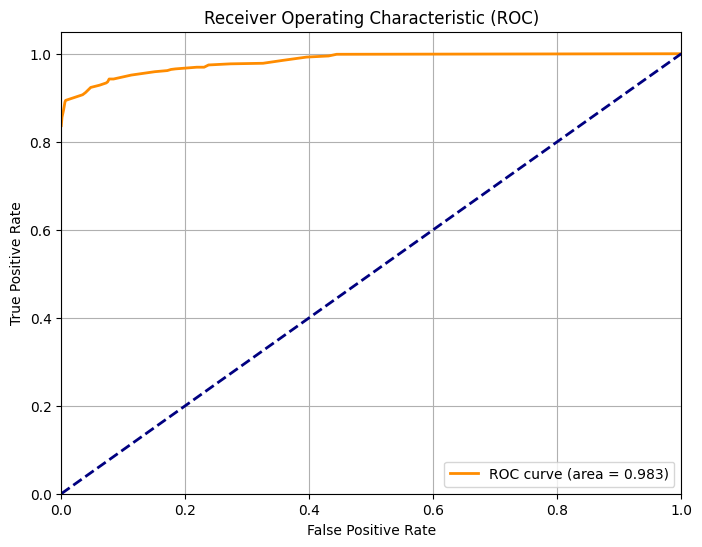

ROC-AUC: 0.9829


In [53]:
def calculate_roc_curve(y_true, y_prob):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    desc_score_indices = np.argsort(y_prob)[::-1]
    y_true_sorted = y_true[desc_score_indices]
    y_prob_sorted = y_prob[desc_score_indices]
    
    tpr_list = []
    fpr_list = []
    
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)
    
    TP = 0
    FP = 0
    
    for i in range(len(y_true)):
        if y_true_sorted[i] == 1:
            TP += 1
        else:
            FP += 1
        
        if i == len(y_true) - 1 or y_prob_sorted[i] != y_prob_sorted[i+1]:
            tpr_list.append(TP / P)
            fpr_list.append(FP / N)
            
    return np.array(fpr_list), np.array(tpr_list)

def calculate_auc(x, y):
    return np.sum(np.diff(x) * (y[:-1] + y[1:]) / 2)

fpr, tpr = calculate_roc_curve(y_test, y_pred_proba)
roc_auc = calculate_auc(np.concatenate(([0], fpr)), np.concatenate(([0], tpr)))

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

### AUC-PR кривая

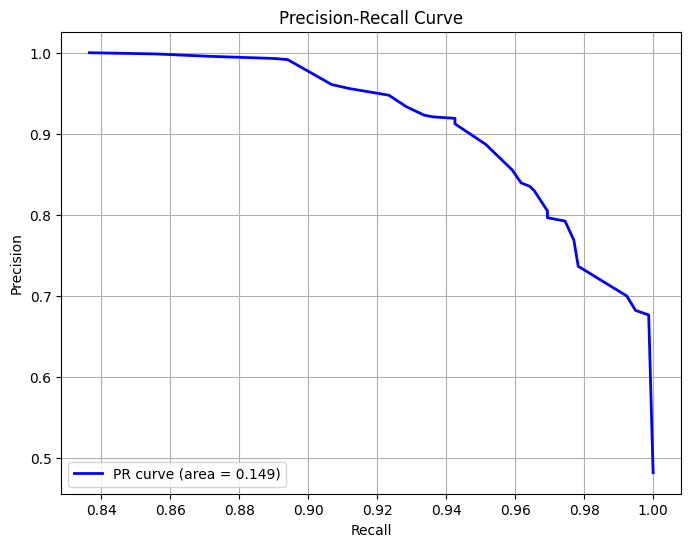

PR-AUC: 0.1488


In [55]:
def calculate_pr_curve(y_true, y_prob):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    desc_score_indices = np.argsort(y_prob)[::-1]
    y_true_sorted = y_true[desc_score_indices]
    y_prob_sorted = y_prob[desc_score_indices]
    
    precision_list = []
    recall_list = []
    
    TP = 0
    FP = 0
    P = np.sum(y_true == 1)
    
    for i in range(len(y_true)):
        if y_true_sorted[i] == 1:
            TP += 1
        else:
            FP += 1
            
        if i == len(y_true) - 1 or y_prob_sorted[i] != y_prob_sorted[i+1]:
            precision_list.append(TP / (TP + FP))
            recall_list.append(TP / P)
            
    return np.array(recall_list), np.array(precision_list)

recalls, precisions = calculate_pr_curve(y_test, y_pred_proba)
pr_auc = calculate_auc(recalls, precisions)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

print(f"PR-AUC: {pr_auc:.4f}")